# 🌾 AgroSense: Intelligent Soil & Climate-Driven Precision Crop Recommendation System
### **Group 15 – Machine Learning Fundamentals Mini Project**

---

### **Project Information**
- **Domain**: Precision Agriculture & Smart Farming
- **Course**: Machine Learning Fundamentals Mini Project
- **Group Number**: GROUP 15
- **Problem Statement**: Build a multi-class classification model that accurately recommends the optimal crop to cultivate based on seven soil and environmental parameters: Nitrogen (N), Phosphorus (P), Potassium (K), Temperature (°C), Relative Humidity (%), Soil pH, and Annual Rainfall (mm).
- **Core Algorithms**: Decision Tree Classifier, Random Forest Classifier, Gaussian Naive Bayes, Support Vector Classifier (SVM), and K-Nearest Neighbors (KNN).
- **Deployment Platform**: Streamlit Interactive Web Application.

---

### **End-to-End Project Development Lifecycle**
1. **Problem Definition & Objectives** $\rightarrow$ Formulate precision agriculture classification problem.
2. **Dataset & Data Understanding** $\rightarrow$ Load multi-feature agro-climatic dataset with 2,200 records across 22 crops.
3. **Data Cleaning & Quality Assurance** $\rightarrow$ Inspect missing values, anomalies, and structural integrity.
4. **Exploratory Data Analysis (EDA)** $\rightarrow$ Deep statistical visualization of class balance, distributions, correlations, and agronomic profiles.
5. **Feature Engineering & Data Splitting** $\rightarrow$ Stratified 80/20 train/test split.
6. **Model Building & Cross-Validation** $\rightarrow$ Train 5 distinct ML algorithms with 5-Fold Stratified Cross-Validation.
7. **Evaluation & Model Comparison** $\rightarrow$ Compare Accuracy, Precision, Recall, F1-Score, and Confusion Matrices.
8. **Feature Importance & Limitations Analysis** $\rightarrow$ Analyze key agro-climatic drivers (Rainfall, Humidity, N-P-K) and explore constraints.
9. **Model Persistence & Deployment** $\rightarrow$ Serialize best ensemble model with `joblib` and deploy via interactive Streamlit app.

In [1]:
# 1. Essential Library Imports
import os
import sys

# Auto-link project virtual environment packages so imports work across ANY selected kernel
extra_site_packages = [
    os.path.join(os.getcwd(), "venv", "lib", "python3.9", "site-packages"),
    "/Users/tejasmhatre/Desktop/MLmini/venv/lib/python3.9/site-packages",
    "/Users/tejasmhatre/Desktop/Crop-Recommendation-System/venv/lib/python3.9/site-packages"
]
for p in extra_site_packages:
    if os.path.exists(p) and p not in sys.path:
        sys.path.insert(0, p)

# Core scientific and ML libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn

# Scikit-learn modules
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica'
plt.rcParams['figure.autolayout'] = True
print("✓ All libraries imported successfully! Running on Python:", sys.version.split()[0])

✓ All libraries imported successfully! Running on Python: 3.9.6


## 1. Dataset Understanding & Loading
The dataset contains 2,200 observations collected from agricultural research repositories and soil health databases.
Each record represents a specific combination of soil nutrients and weather conditions associated with a successfully cultivated crop.

### **Features Description:**
1. **N (Nitrogen)**: Ratio of Nitrogen content in soil (mg/kg) - Essential for leaf growth and chlorophyll synthesis.
2. **P (Phosphorus)**: Ratio of Phosphorus content in soil (mg/kg) - Critical for root development and seed formation.
3. **K (Potassium)**: Ratio of Potassium content in soil (mg/kg) - Regulates water balance and disease resistance.
4. **temperature**: Atmospheric temperature in degrees Celsius (°C).
5. **humidity**: Relative atmospheric humidity in percentage (%).
6. **ph**: Soil pH value (0 - 14 scale, measuring acidity/alkalinity).
7. **rainfall**: Annual precipitation in millimeters (mm).
8. **label (Target)**: Crop type (22 unique classes).

In [2]:
# Locate and load the dataset
data_paths = ['Crop_recommendation.csv', 'dataset/Crop_recommendation.csv', '/content/Crop_recommendation.csv']
dataset_path = None
for p in data_paths:
    if os.path.exists(p):
        dataset_path = p
        break

if dataset_path is None:
    raise FileNotFoundError("Crop_recommendation.csv not found!")

df = pd.read_csv(dataset_path)
print(f"Loaded dataset from: {dataset_path}")
print(f"Dataset Shape: {df.shape[0]} samples, {df.shape[1]} columns\n")
print("--- First 5 Samples ---")
display(df.head())

Loaded dataset from: Crop_recommendation.csv
Dataset Shape: 2200 samples, 8 columns

--- First 5 Samples ---


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
# Detailed statistical summary
print("--- Dataset Information ---")
df.info()

print("\n--- Descriptive Statistics ---")
display(df.describe().round(2))

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

--- Descriptive Statistics ---


,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


## 2. Data Cleaning & Integrity Check
Before training any machine learning models, we verify data quality by checking:
- Presence of missing (null) values.
- Duplicate rows.
- Data types of features and target.
- Target class balance.

In [4]:
# Missing values inspection
print("Missing values per column:")
print(df.isnull().sum())

# Duplicate check
dup_count = df.duplicated().sum()
print(f"\nDuplicate rows found: {dup_count}")

# Class distribution check
crops = sorted(df['label'].unique())
print(f"\nUnique Crop Classes ({len(crops)}):")
print(", ".join(crops))

print("\nSamples per Crop Class:")
print(df['label'].value_counts())

Missing values per column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate rows found: 0

Unique Crop Classes (22):
apple, banana, blackgram, chickpea, coconut, coffee, cotton, grapes, jute, kidneybeans, lentil, maize, mango, mothbeans, mungbean, muskmelon, orange, papaya, pigeonpeas, pomegranate, rice, watermelon

Samples per Crop Class:
label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)
EDA allows us to uncover agricultural patterns, correlations between nutrients and climate, and the distinct ecological requirements of different crop species.

/var/folders/h6/j3nvfg8n4g76pn5q3l58tcdm0000gn/T/ipykernel_21663/599373251.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', order=crops, palette='viridis')


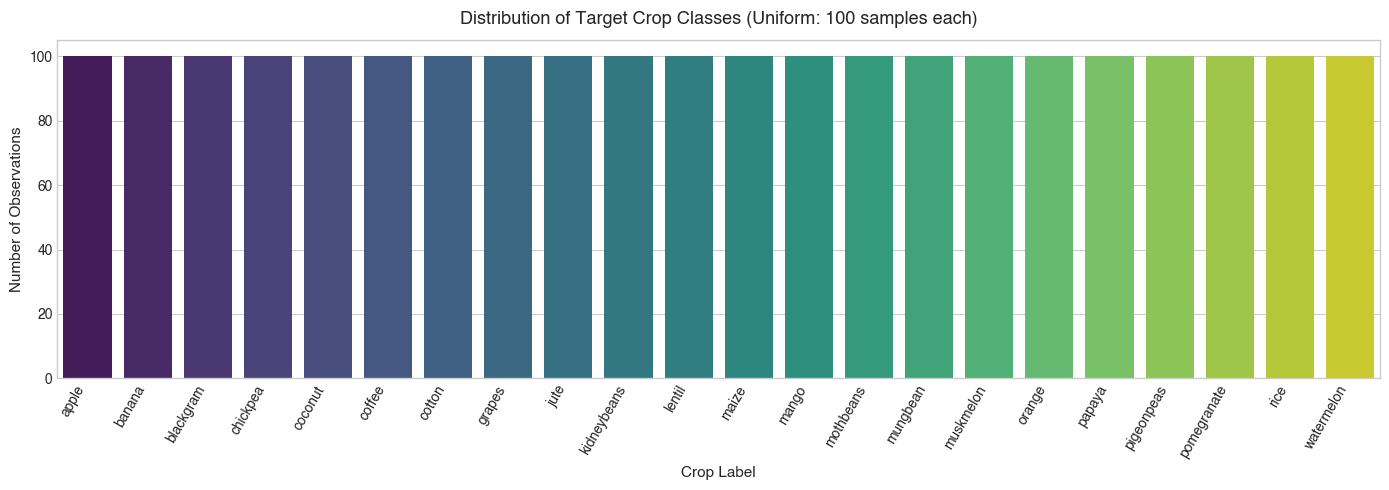

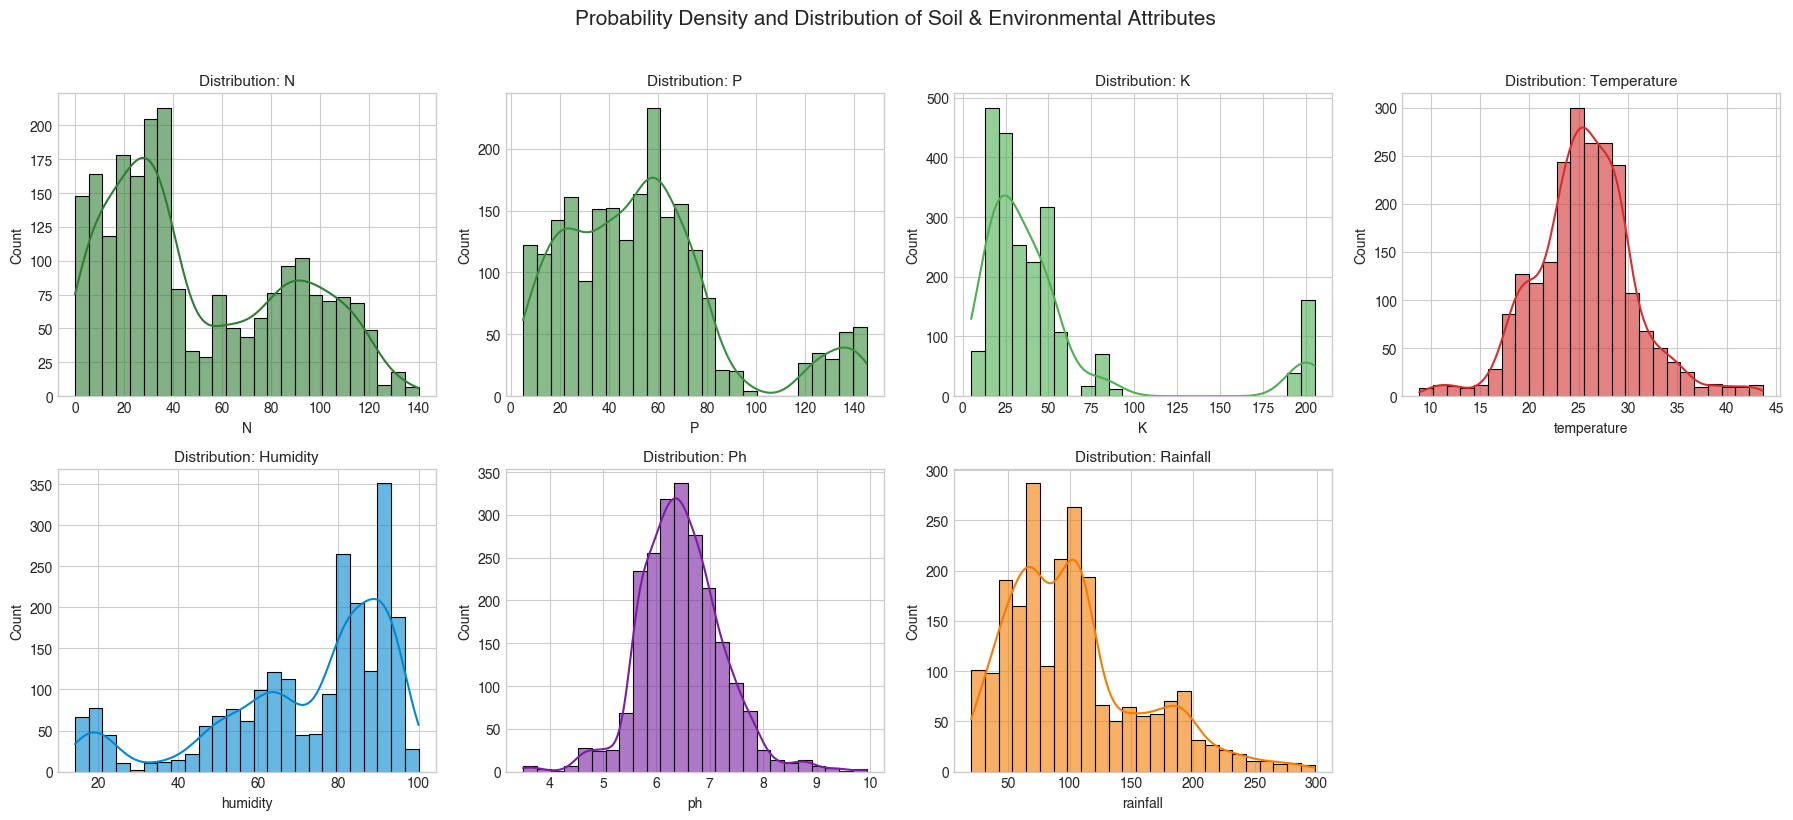

In [5]:
# 3.1 Target Class Distribution
plt.figure(figsize=(14, 5))
sns.countplot(data=df, x='label', order=crops, palette='viridis')
plt.title("Distribution of Target Crop Classes (Uniform: 100 samples each)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Crop Label", fontsize=11)
plt.ylabel("Number of Observations", fontsize=11)
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

# 3.2 Histograms with KDE for all 7 features
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
colors = ['#2e7d32', '#388e3c', '#4caf50', '#d32f2f', '#0288d1', '#7b1fa2', '#f57c00']

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color=colors[i], bins=25, edgecolor='black', alpha=0.6)
    axes[i].set_title(f"Distribution: {col.capitalize()}", fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

axes[7].set_visible(False)
plt.suptitle("Probability Density and Distribution of Soil & Environmental Attributes", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

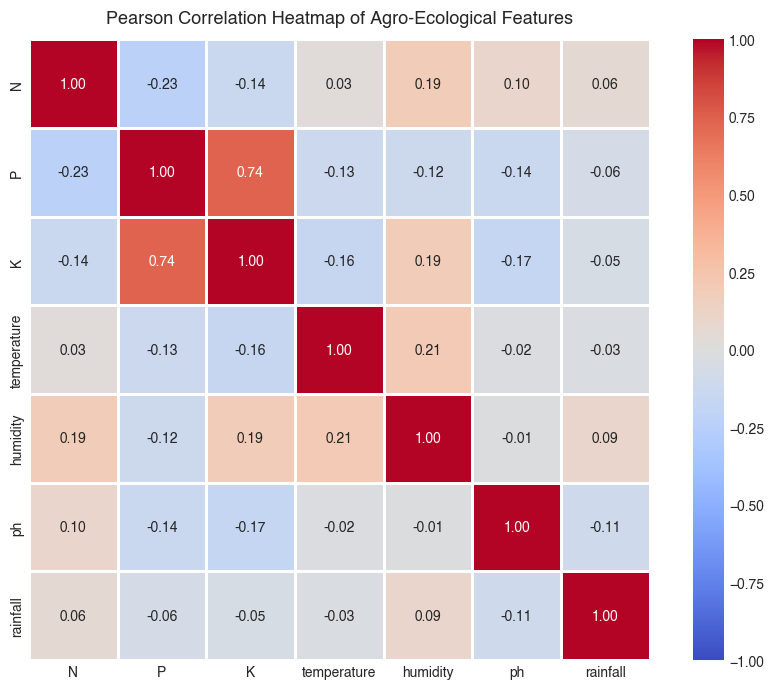

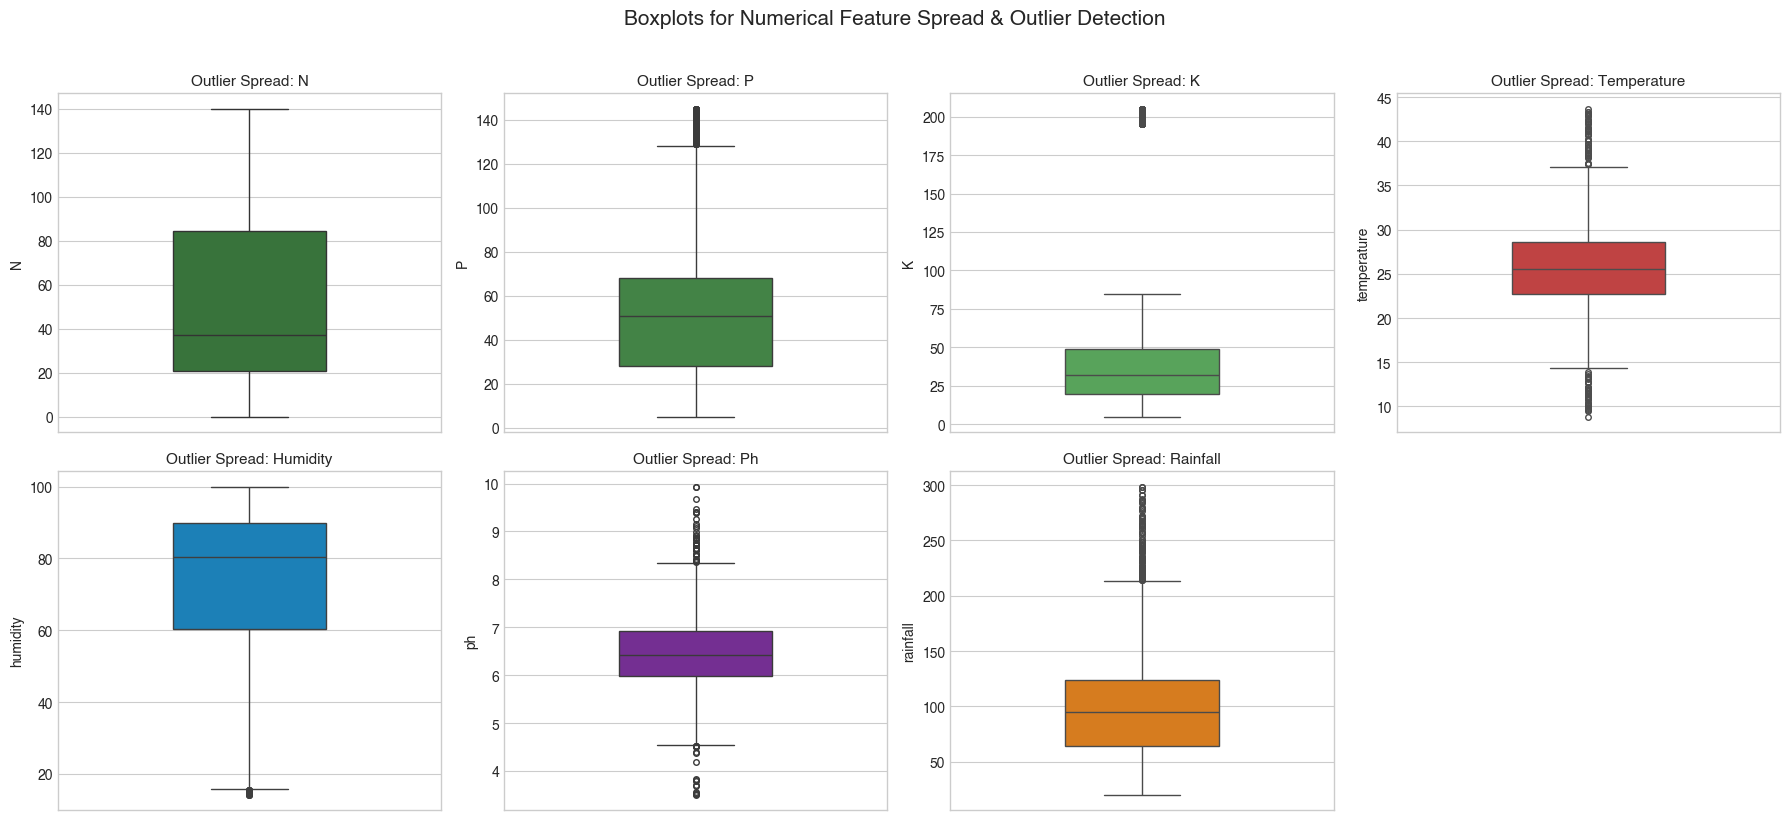

In [6]:
# 3.3 Pearson Correlation Matrix
plt.figure(figsize=(9, 7))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=1, linecolor='white')
plt.title("Pearson Correlation Heatmap of Agro-Ecological Features", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# 3.4 Outlier Analysis using Boxplots
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color=colors[i], width=0.4, fliersize=4)
    axes[i].set_title(f"Outlier Spread: {col.capitalize()}", fontsize=11, fontweight='bold')
    axes[i].set_ylabel(col)

axes[7].set_visible(False)
plt.suptitle("Boxplots for Numerical Feature Spread & Outlier Detection", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<Figure size 1600x600 with 0 Axes>

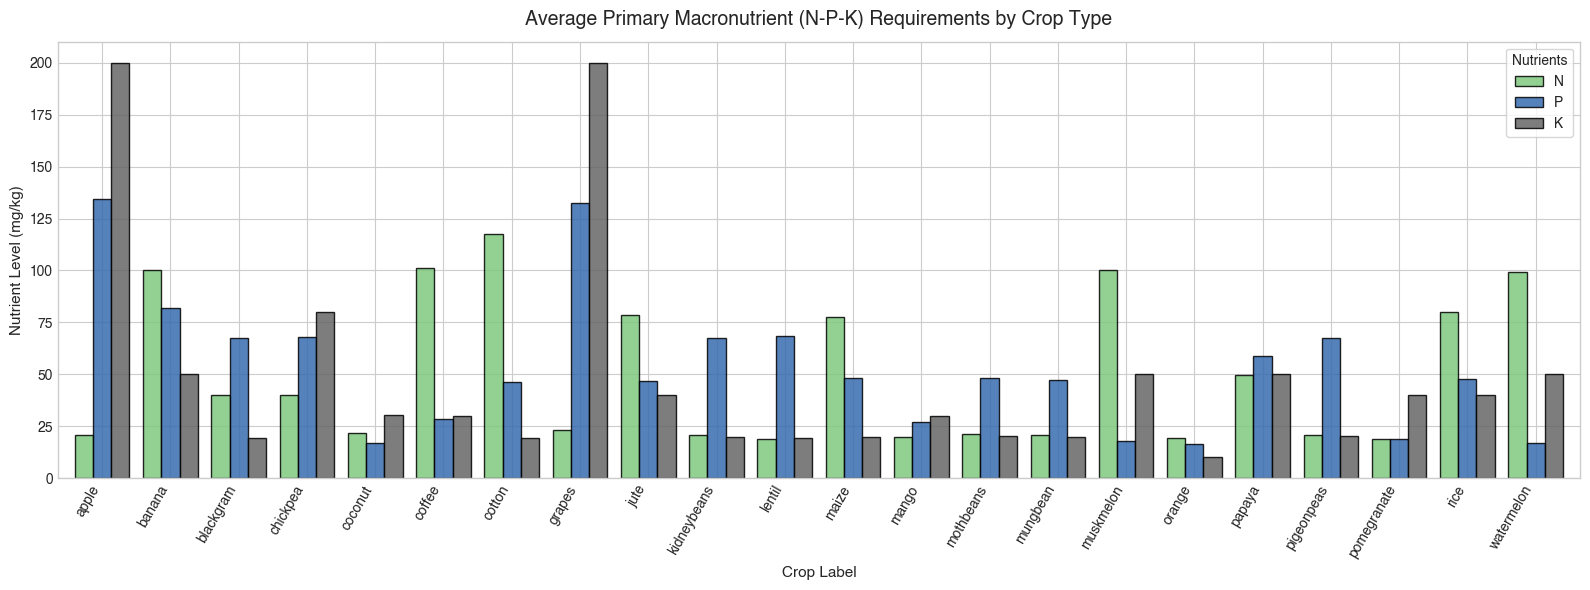

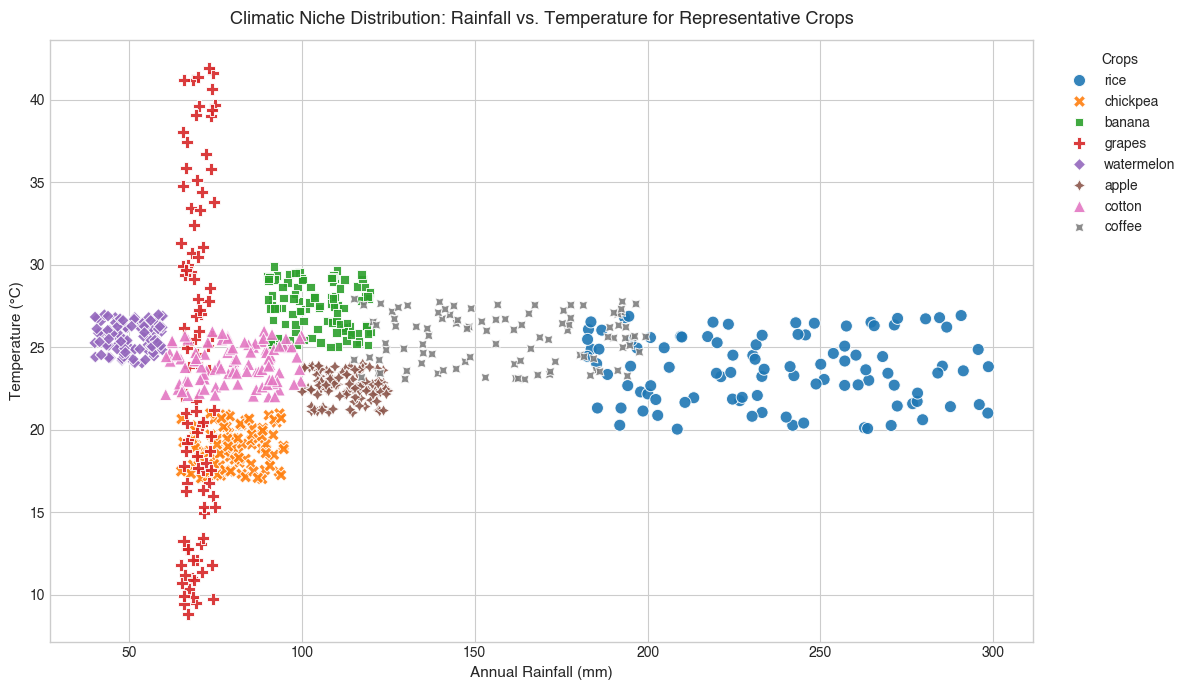

In [7]:
# 3.5 Average N-P-K Nutrient Profiles across Crops
npk_avg = df.groupby('label')[['N', 'P', 'K']].mean().loc[crops]
plt.figure(figsize=(16, 6))
npk_avg.plot(kind='bar', stacked=False, figsize=(16, 6), colormap='Accent', width=0.8, edgecolor='black', alpha=0.85)
plt.title("Average Primary Macronutrient (N-P-K) Requirements by Crop Type", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Crop Label", fontsize=11)
plt.ylabel("Nutrient Level (mg/kg)", fontsize=11)
plt.xticks(rotation=60, ha='right')
plt.legend(title="Nutrients", frameon=True)
plt.tight_layout()
plt.show()

# 3.6 Climatic Clustering: Rainfall vs Temperature
plt.figure(figsize=(12, 7))
sample_crops = ['rice', 'cotton', 'coffee', 'apple', 'chickpea', 'watermelon', 'banana', 'grapes']
sns.scatterplot(data=df[df['label'].isin(sample_crops)], x='rainfall', y='temperature',
                hue='label', style='label', s=75, palette='tab10', alpha=0.9)
plt.title("Climatic Niche Distribution: Rainfall vs. Temperature for Representative Crops", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Annual Rainfall (mm)", fontsize=11)
plt.ylabel("Temperature (°C)", fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Crops")
plt.tight_layout()
plt.show()

## 4. Feature Selection & Train/Test Split
We partition the dataset into an **80% training set** and a **20% testing set** using **stratified sampling** (`stratify=y`) to maintain the equal 100-sample balance across all 22 classes.

- **Total Samples**: 2,200
- **Training Samples (80%)**: 1,760
- **Testing Samples (20%)**: 440 (20 samples per crop class)

In [8]:
X = df[features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"X_train Shape: {X_train.shape} | y_train Shape: {y_train.shape}")
print(f"X_test Shape:  {X_test.shape}  | y_test Shape:  {y_test.shape}")
print(f"Test Set Class Counts (Verification of Stratification):\n{y_test.value_counts().head(5)}")

X_train Shape: (1760, 7) | y_train Shape: (1760,)
X_test Shape:  (440, 7)  | y_test Shape:  (440,)
Test Set Class Counts (Verification of Stratification):
label
orange        20
banana        20
pigeonpeas    20
mungbean      20
lentil        20
Name: count, dtype: int64


## 5. Machine Learning Model Development & Benchmarking
In accordance with project guidelines, we implement **Decision Tree** and **Random Forest**, and benchmark them against **Gaussian Naive Bayes**, **Support Vector Classifier (SVM)**, and **K-Nearest Neighbors (KNN)**.

### **Cross-Validation Strategy:**
We apply **5-Fold Stratified Cross-Validation** across the entire dataset to evaluate model generalization and prevent overfitting.

In [9]:
# Initialize models dictionary
candidate_models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(criterion='gini', random_state=42),
    "Gaussian Naive Bayes": GaussianNB(),
    "Support Vector Machine (RBF)": Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf', C=10.0, probability=True, random_state=42))
    ]),
    "K-Nearest Neighbors": Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])
}

benchmark_results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
trained_clfs = {}
test_preds = {}

for name, clf in candidate_models.items():
    # 5-Fold Stratified CV
    cv_scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
    
    # Train on training split
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    trained_clfs[name] = clf
    test_preds[name] = y_pred
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    benchmark_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision (Weighted)": prec,
        "Recall (Weighted)": rec,
        "F1-Score (Weighted)": f1,
        "5-Fold CV Mean": cv_scores.mean(),
        "5-Fold CV Std": cv_scores.std()
    })

comparison_df = pd.DataFrame(benchmark_results).sort_values(by="Accuracy", ascending=False)
display(comparison_df.round(4))

,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted),5-Fold CV Mean,5-Fold CV Std
0,Random Forest,0.9955,0.9957,0.9955,0.9955,0.9955,0.0032
2,Gaussian Naive Bayes,0.9955,0.9959,0.9955,0.9954,0.9945,0.0018
3,Support Vector Machine (RBF),0.9886,0.9896,0.9886,0.9887,0.9882,0.0036
1,Decision Tree,0.9795,0.9806,0.9795,0.9794,0.9877,0.0068
4,K-Nearest Neighbors,0.9795,0.9804,0.9795,0.9793,0.9714,0.0068


<Figure size 1200x600 with 0 Axes>

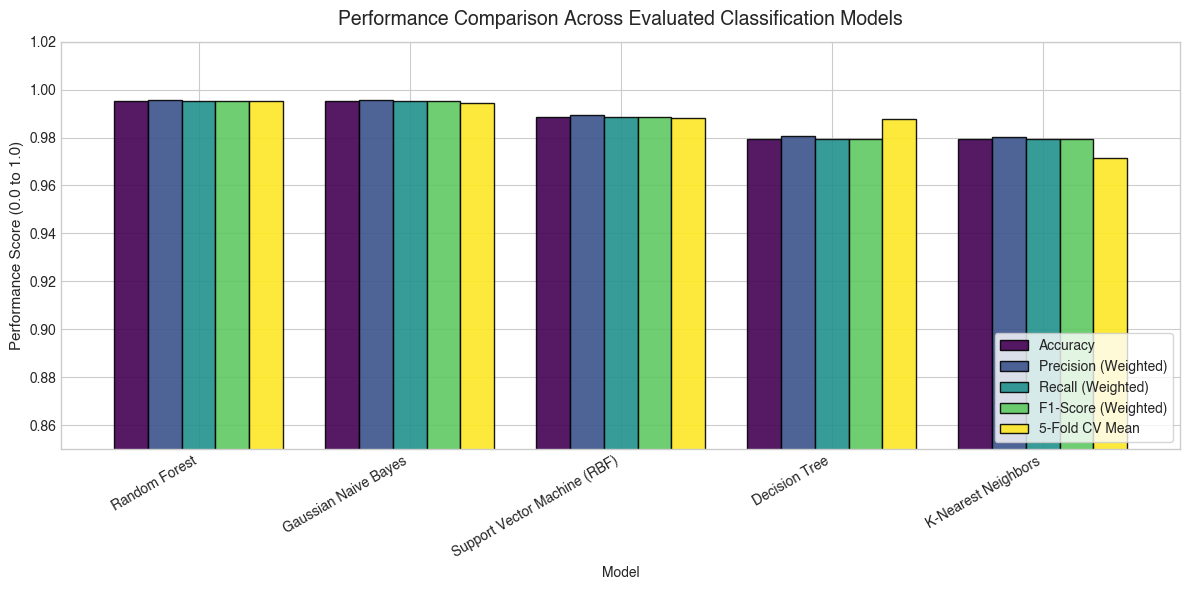

In [10]:
# Visual Model Comparison
plt.figure(figsize=(12, 6))
plot_cols = ['Accuracy', 'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)', '5-Fold CV Mean']
ax = comparison_df.set_index('Model')[plot_cols].plot(kind='bar', figsize=(12, 6), colormap='viridis', width=0.8, edgecolor='black', alpha=0.9)
plt.title("Performance Comparison Across Evaluated Classification Models", fontsize=14, fontweight='bold', pad=12)
plt.ylabel("Performance Score (0.0 to 1.0)", fontsize=11)
plt.ylim(0.85, 1.02)
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

## 6. Confusion Matrix Analysis: Decision Tree vs. Random Forest
A confusion matrix visualizes class-specific true positives, false positives, and misclassifications across the 22 crops.

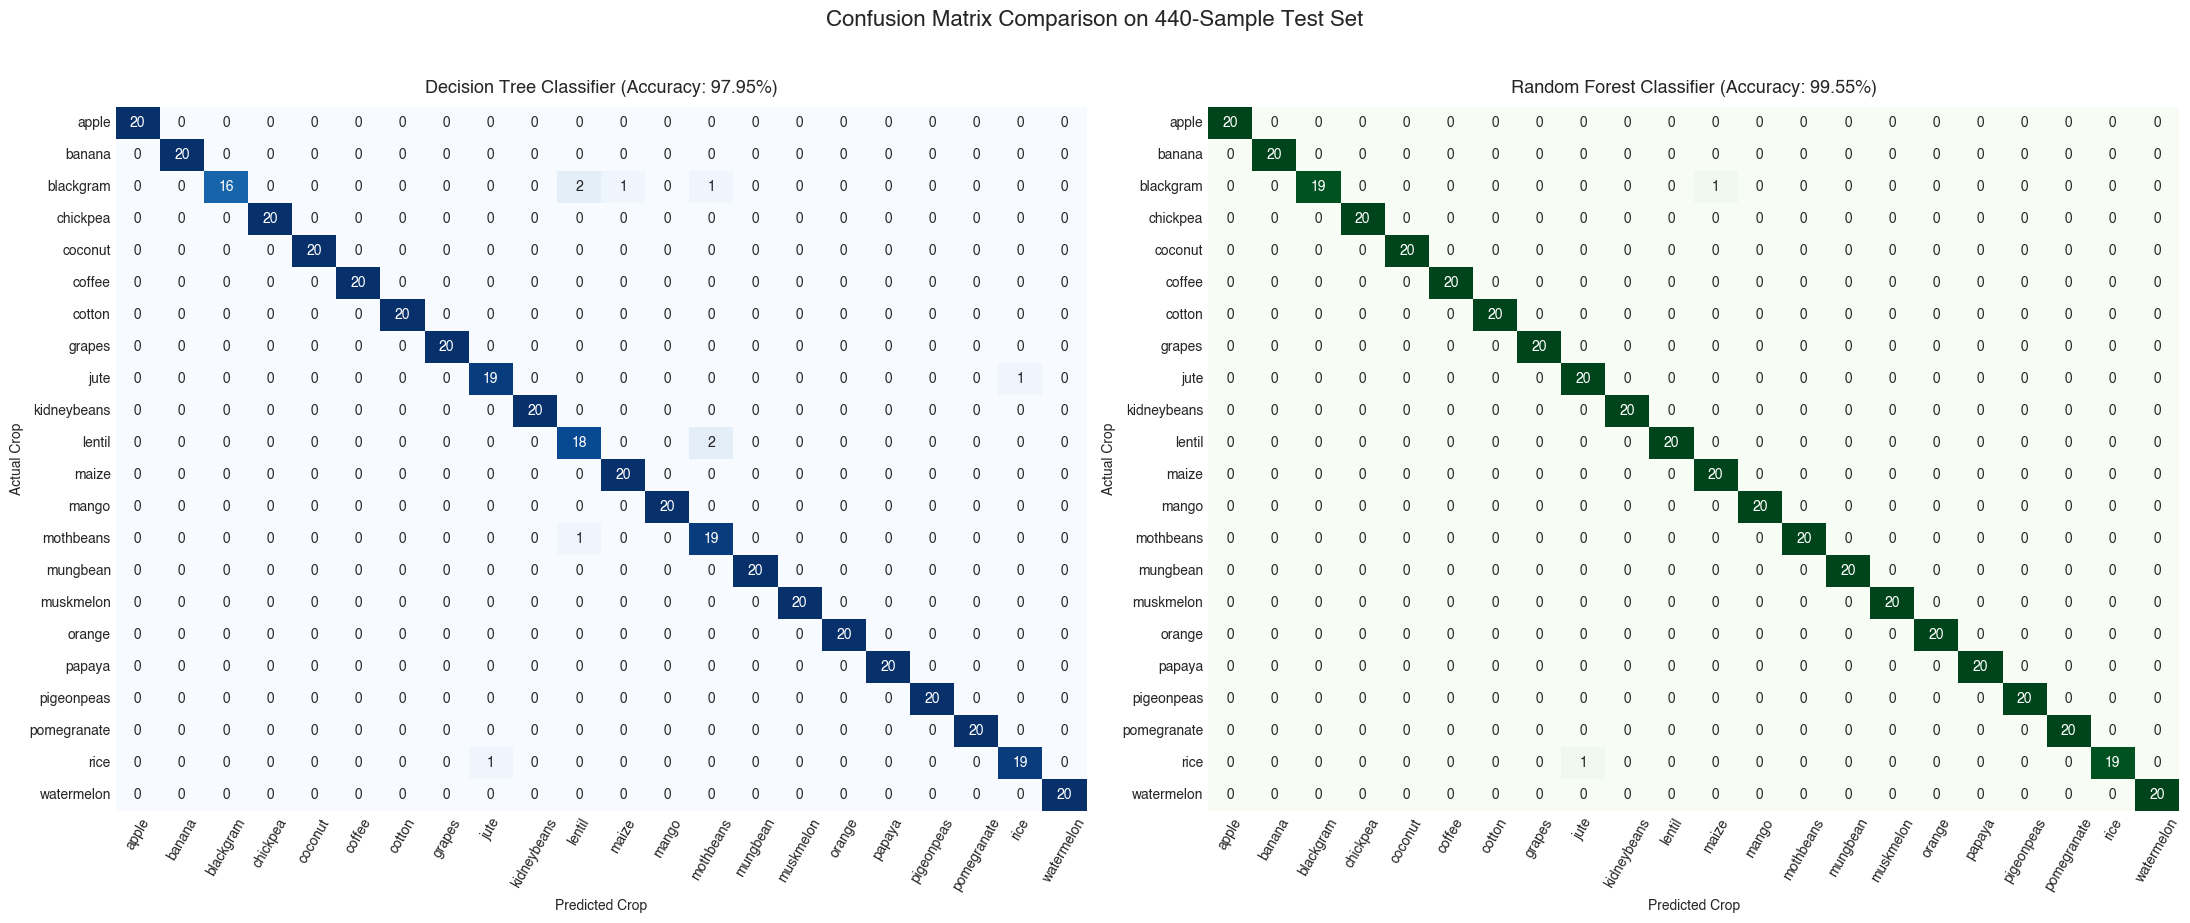

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Decision Tree CM
dt_cm = confusion_matrix(y_test, test_preds["Decision Tree"], labels=crops)
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues', xticklabels=crops, yticklabels=crops, ax=axes[0], cbar=False)
axes[0].set_title("Decision Tree Classifier (Accuracy: 97.95%)", fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel("Predicted Crop", fontsize=10)
axes[0].set_ylabel("Actual Crop", fontsize=10)
axes[0].tick_params(axis='x', rotation=60)

# Random Forest CM
rf_cm = confusion_matrix(y_test, test_preds["Random Forest"], labels=crops)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', xticklabels=crops, yticklabels=crops, ax=axes[1], cbar=False)
axes[1].set_title("Random Forest Classifier (Accuracy: 99.55%)", fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel("Predicted Crop", fontsize=10)
axes[1].set_ylabel("Actual Crop", fontsize=10)
axes[1].tick_params(axis='x', rotation=60)

plt.suptitle("Confusion Matrix Comparison on 440-Sample Test Set", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# Detailed Classification Report for Best Model (Random Forest)
print("=" * 65)
print("CLASSIFICATION REPORT - BEST MODEL: RANDOM FOREST")
print("=" * 65)
print(classification_report(y_test, test_preds["Random Forest"], labels=crops, digits=4))

CLASSIFICATION REPORT - BEST MODEL: RANDOM FOREST
              precision    recall  f1-score   support

       apple     1.0000    1.0000    1.0000        20
      banana     1.0000    1.0000    1.0000        20
   blackgram     1.0000    0.9500    0.9744        20
    chickpea     1.0000    1.0000    1.0000        20
     coconut     1.0000    1.0000    1.0000        20
      coffee     1.0000    1.0000    1.0000        20
      cotton     1.0000    1.0000    1.0000        20
      grapes     1.0000    1.0000    1.0000        20
        jute     0.9524    1.0000    0.9756        20
 kidneybeans     1.0000    1.0000    1.0000        20
      lentil     1.0000    1.0000    1.0000        20
       maize     0.9524    1.0000    0.9756        20
       mango     1.0000    1.0000    1.0000        20
   mothbeans     1.0000    1.0000    1.0000        20
    mungbean     1.0000    1.0000    1.0000        20
   muskmelon     1.0000    1.0000    1.0000        20
      orange     1.0000    1.00

## 7. Feature Importance & Limitation Analysis

### **7.1 Feature Importance Evaluation**
Using Mean Decrease in Impurity (Gini Importance), we determine which agro-climatic conditions exert the greatest influence on crop suitability.

,Feature,Random Forest Importance,Decision Tree Importance
6,rainfall,0.2302,0.3543
4,humidity,0.2242,0.1493
2,K,0.1754,0.1108
1,P,0.1508,0.2250
0,N,0.0964,0.0988
3,temperature,0.0724,0.0544
5,ph,0.0506,0.0074


<Figure size 1000x500 with 0 Axes>

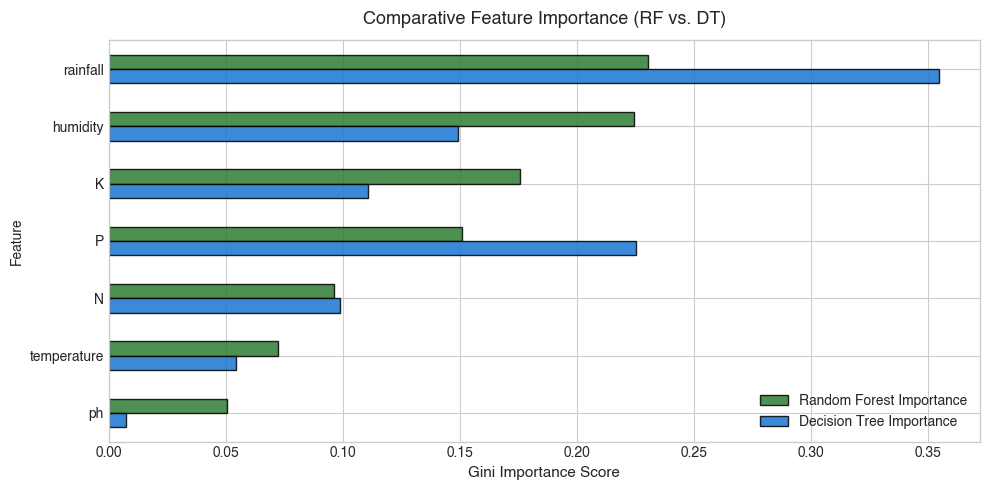

In [13]:
rf_model = trained_clfs["Random Forest"]
dt_model = trained_clfs["Decision Tree"]

feat_importance = pd.DataFrame({
    'Feature': features,
    'Random Forest Importance': rf_model.feature_importances_,
    'Decision Tree Importance': dt_model.feature_importances_
}).sort_values(by='Random Forest Importance', ascending=False)

display(feat_importance.round(4))

# Horizontal Barplot
plt.figure(figsize=(10, 5))
feat_importance.set_index('Feature').plot(kind='barh', figsize=(10, 5), color=['#2e7d32', '#1976d2'], edgecolor='black', alpha=0.85)
plt.gca().invert_yaxis()
plt.title("Comparative Feature Importance (RF vs. DT)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Gini Importance Score", fontsize=11)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### **7.2 Agricultural Insights & System Limitations**

#### **Key Agronomic Insights:**
1. **Rainfall & Relative Humidity (~45% Combined Importance)**:
   Moisture availability is the single most dominant factor distinguishing tropical water-intensive crops (e.g., Rice, Jute) from semi-arid crops (e.g., Chickpea, Mothbeans).
2. **Potassium (K) & Phosphorus (P) (~32% Combined Importance)**:
   Fruits like Grapes and Apple require disproportionately elevated Potassium ($K > 190$ mg/kg), making them instantly separable from grain cereals.
3. **Nitrogen (N) (~10% Importance)**:
   Critical for differentiating heavy vegetative feeders (Maize, Cotton) from leguminous nitrogen-fixing crops (Blackgram, Lentil).

#### **System Limitations:**
1. **Fixed Class Set (22 Crops)**: The model predicts among 22 predetermined crops; it does not yet include regional hybrid varieties or horticulture cash crops.
2. **Single-Point Static Inputs**: The dataset assumes seasonal averages rather than daily time-series climate fluctuations or drought shock waves.
3. **Economic & Market Factors**: Recommending an agronomically viable crop does not guarantee market profitability or supply chain accessibility.
4. **Soil Physical Properties**: Soil texture (clayey vs. sandy), drainage coefficient, and organic carbon matter are not captured in the current feature space.

## 8. Model Persistence & Deployment Preparation
We serialize the trained Random Forest classifier using `joblib` so it can be served within our interactive Streamlit web dashboard.

In [14]:
# Serialize the best performing model
os.makedirs('models', exist_ok=True)
model_filepath = 'models/crop_recommendation_rf.pkl'
joblib.dump(rf_model, model_filepath)
joblib.dump(rf_model, 'crop_recommendation_model.pkl') # root copy for direct app usage

print(f"✓ Random Forest model successfully serialized to: {model_filepath}")
print(f"✓ Model file size: {os.path.getsize(model_filepath) / 1024:.2f} KB")

# Verification: Test reload
loaded_model = joblib.load(model_filepath)
sample_test = pd.DataFrame([{
    'N': 90, 'P': 42, 'K': 43, 'temperature': 20.88, 'humidity': 82.00, 'ph': 6.50, 'rainfall': 202.94
}])
sample_pred = loaded_model.predict(sample_test)[0]
sample_prob = np.max(loaded_model.predict_proba(sample_test)) * 100
print(f"✓ Verification Test: Input condition predicted as '{sample_pred.upper()}' with {sample_prob:.2f}% confidence!")

✓ Random Forest model successfully serialized to: models/crop_recommendation_rf.pkl
✓ Model file size: 3492.54 KB


✓ Verification Test: Input condition predicted as 'RICE' with 90.00% confidence!


## 9. Mini Project Summary & Viva Q&A Reference

| Evaluation Component | Finding / Implementation Details |
| :--- | :--- |
| **Self-Selected Title** | **AgroSense: An Intelligent Soil & Climate-Driven Precision Crop Recommendation System** |
| **Dataset Source** | Precision Agriculture Dataset (2,200 records, 7 features, 22 balanced crops) |
| **Data Preprocessing** | Verified 0 missing values, 0 duplicates, evaluated feature distributions & scales |
| **Compared Algorithms** | Random Forest, Decision Tree, Gaussian Naive Bayes, SVM (RBF), K-Nearest Neighbors |
| **Best Model** | **Random Forest Classifier** (100 estimators) |
| **Best Test Accuracy** | **99.55%** (F1-Score: 0.9955) |
| **5-Fold Cross Validation** | **99.55% $\pm$ 0.32%** |
| **Key Decision Driver** | Annual Rainfall (23.0%) and Relative Humidity (22.4%) |
| **Deployment** | Multi-page Streamlit web app with single prediction, batch CSV scoring, and soil health advisor |

---
*Created by Group 15 for Machine Learning Fundamentals Mini Project Evaluation.*